In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import heapq
import itertools

In [2]:
def load_maze(fp):
    with open(fp) as f: lines = f.readlines()
    return np.array([list(map(int,l.split())) for l in lines if l.strip()])

DIRS = [(0,1),(1,0),(0,-1),(-1,0)]

In [4]:
# Thuật toán BFS từ main.ipynb (đã thêm code lưu lại các node đã duyệt - visited)
def bfs_demo(maze):
    rows,cols = maze.shape
    start,end = (1,0),(rows-2,cols-1)
    q = deque([(start, [start])])
    v = set([start])
    visited_order = []
    
    while q:
        (r,c), p = q.popleft()
        visited_order.append((r,c))
        if (r,c)==end: 
            return p, visited_order
        for dr,dc in DIRS:
            nr,nc=r+dr,c+dc
            if 0<=nr<rows and 0<=nc<cols and maze[nr,nc]==0 and (nr,nc) not in v:
                v.add((nr,nc))
                q.append(((nr,nc), p+[(nr,nc)]))
    return None, visited_order

In [5]:
# Thuật toán GBFS từ main2.ipynb (đã thêm code lưu lại các node đã duyệt - visited)
def gbfs_demo(maze):
    rows,cols = maze.shape
    start,end = (1,0),(rows-2,cols-1)
    
    h = lambda r,c: abs(r-end[0])+abs(c-end[1])
    counter = itertools.count()
    heap = [(h(*start), next(counter), start[0], start[1], [start])]
    vis = set()
    visited_order = []
    
    while heap:
        _, _, r, c, path = heapq.heappop(heap)
        
        if (r,c) == end:
            visited_order.append((r,c))
            return path, visited_order
            
        if (r,c) in vis: continue
        vis.add((r,c))
        visited_order.append((r,c))
        
        for dr,dc in DIRS:
            nr,nc = r+dr, c+dc
            if 0<=nr<rows and 0<=nc<cols and maze[nr,nc]==0 and (nr,nc) not in vis:
                heapq.heappush(heap, (h(nr,nc), next(counter), nr, nc, path+[(nr,nc)]))
                
    return None, visited_order

In [6]:
# Hàm vẽ trực quan hóa
def visualize_maze(maze, path, visited, title="Maze Solution"):
    plt.figure(figsize=(10, 10))
    
    # Vẽ bản đồ maze (tường màu đen, đường đi màu trắng)
    cmap = plt.cm.binary
    plt.imshow(maze, cmap=cmap)
    
    # Vẽ các node đã duyệt (màu xanh)
    if visited:
        vis_arr = np.array(visited)
        plt.scatter(vis_arr[:, 1], vis_arr[:, 0], c='cyan', s=15, alpha=0.6, label='Explored / Đã duyệt (Màu xanh)')
        
    # Vẽ đường đi tìm được (màu đỏ)
    if path:
        path_arr = np.array(path)
        plt.plot(path_arr[:, 1], path_arr[:, 0], c='red', linewidth=2.5, label='Escape Path (Đường thoát - Đỏ)')
        
    # Đánh dấu Start và End
    rows, cols = maze.shape
    start, end = (1, 0), (rows-2, cols-1)
    plt.scatter(start[1], start[0], c='green', s=100, marker='s', label='Start')
    plt.scatter(end[1], end[0], c='blue', s=100, marker='s', label='End')
    
    plt.title(f"{title}\nTổng số thao tác (Số ô đã duyệt): {len(visited)} | Độ dài đường thoát: {len(path)}", fontsize=14)
    plt.legend(loc='upper right')
    plt.axis('off')
    plt.show()

--------------------------------------------------
1. Đang chạy thuật toán từ main (BFS)...
-> TỔNG SỐ THAO TÁC ĐỂ THOÁT (phần màu xanh): 6150


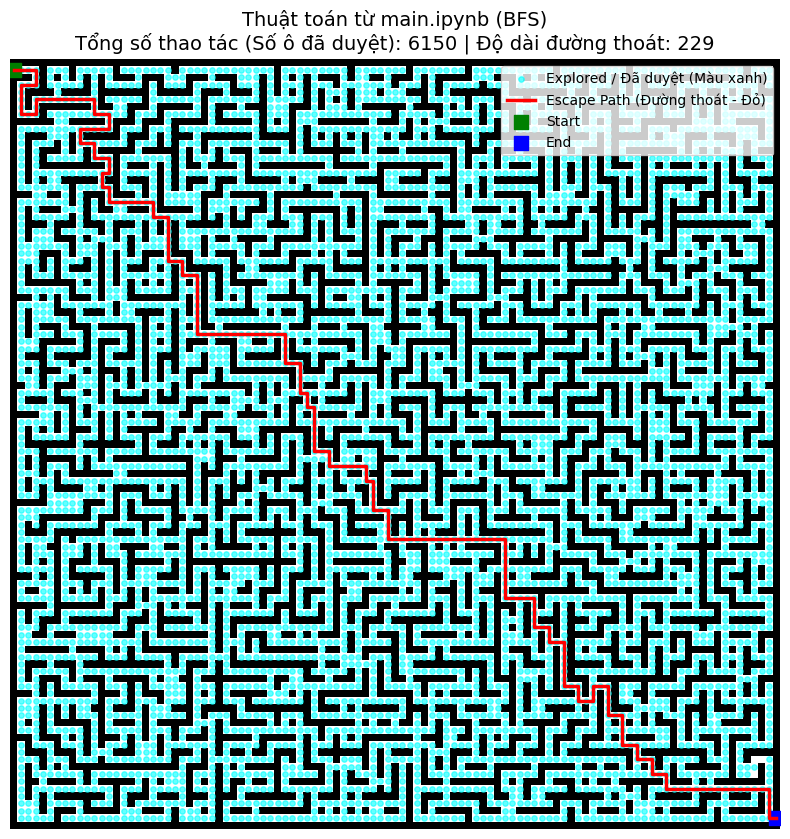

--------------------------------------------------
2. Đang chạy thuật toán từ main2 (GBFS)...
-> TỔNG SỐ THAO TÁC ĐỂ THOÁT (phần màu xanh): 344


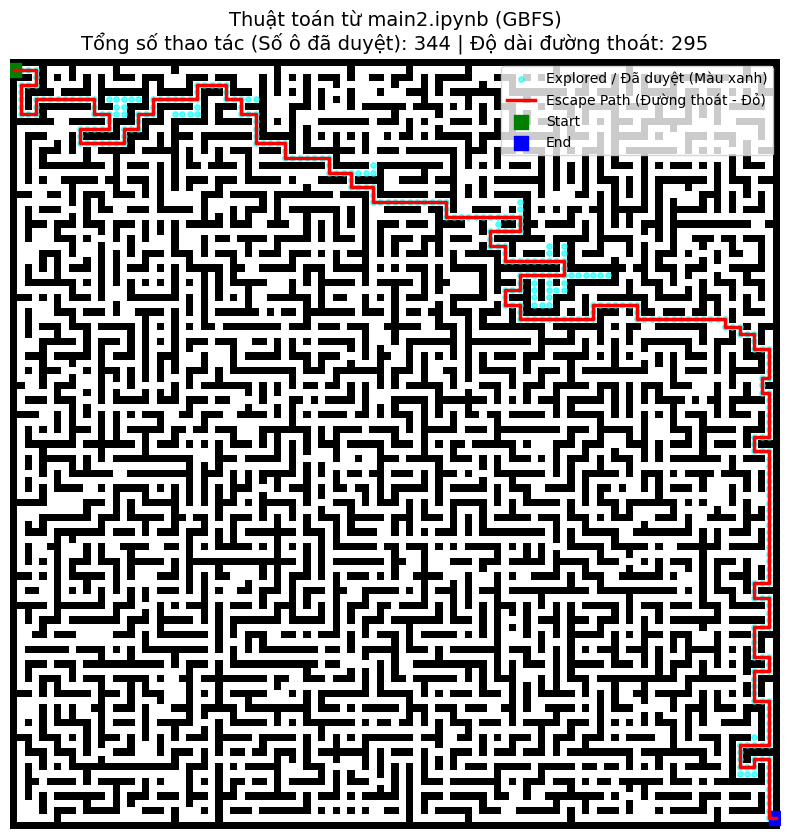

In [7]:
# Chạy thử demo trực quan với maze0_dim52.txt
maze_path = 'imperfect_maze/maze0_dim52.txt'
if not os.path.exists(maze_path):
    print("Không tìm thấy file, hãy thay đổi đường dẫn maze_path")
else:
    maze = load_maze(maze_path)
    
    print("--------------------------------------------------")
    print("1. Đang chạy thuật toán từ main (BFS)...")
    path_bfs, vis_bfs = bfs_demo(maze)
    print(f"-> TỔNG SỐ THAO TÁC ĐỂ THOÁT (phần màu xanh): {len(vis_bfs)}")
    visualize_maze(maze, path_bfs, vis_bfs, "Thuật toán từ main.ipynb (BFS)")
    
    print("--------------------------------------------------")
    print("2. Đang chạy thuật toán từ main2 (GBFS)...")
    path_gbfs, vis_gbfs = gbfs_demo(maze)
    print(f"-> TỔNG SỐ THAO TÁC ĐỂ THOÁT (phần màu xanh): {len(vis_gbfs)}")
    visualize_maze(maze, path_gbfs, vis_gbfs, "Thuật toán từ main2.ipynb (GBFS)")


In [4]:
import requests
import json

response = requests.get(
  url="https://openrouter.ai/api/v1/key",
  headers={
    "Authorization": f"YOUR_OPENROUTER_API_KEY"
  }
)

print(json.dumps(response.json(), indent=2))

{
  "error": {
    "message": "Missing Authentication header",
    "code": 401
  }
}


In [2]:
!pip install requests

  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached charset_normalizer-3.4.7-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.5.20-py3-none-any.whl.metadata (2.5 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached certifi-2026.5.20-py3-none-any.whl (134 kB)
Using cached charset_normalizer-3.4.7-cp312-cp312-win_amd64.whl (159 kB)
Using cached urllib3-2.7.0-py3-none-any.whl (131 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
